<a href="https://colab.research.google.com/github/Davdesigner/AminoRice/blob/main/AminoRice_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AminoRice: Rice Quality Assessment Using Computer Vision
##Project overview
AminoRice is an AI-powered mobile-integrated application designed to automatically assess rice grain quality using computer vision and deep learning techniques. The system analyzes uploaded images of rice samples and predicts key quality indicators such as grain integrity, defects, and overall grade.

The core of AminoRice is a Convolutional Neural Network (CNN) trained on labeled rice grain datasets. The model processes image inputs, extracts visual features, and generates quality predictions that assist farmers, traders, and consumers in making data-driven decisions.



### Mount Drive and Define Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
Train = "/content/drive/MyDrive/Mission Capstone/Dataset/Train.csv"
Test = "/content/drive/MyDrive/Mission Capstone/Dataset/Test.csv"

DRIVE_IMAGE_PATH = "/content/drive/MyDrive/rice_dataset/images"
LOCAL_IMAGE_PATH = "/content/images"

### Copy Images to Local Runtime for Faster Training

In [4]:
!rm -rf /content/images
!cp -r "/content/drive/MyDrive/rice_dataset/images" /content/

^C


In [ ]:
import os

print("Images copied:", len(os.listdir(LOCAL_IMAGE_PATH)))
print("Sample files:", os.listdir(LOCAL_IMAGE_PATH)[:5])

Images copied: 1341
Sample files: ['ID_380673.png', 'ID_BB04AF.png', 'ID_5D616D.png', 'ID_154384.png', 'ID_3546AB.png']


### Load Train and Test Data

In [ ]:
import pandas as pd
import numpy as np

train_df = pd.read_csv(Train)
test_df = pd.read_csv(Test)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())

Train shape: (938, 17)
Test shape: (403, 2)


,ID,Comment,Count,Broken_Count,Long_Count,Medium_Count,Black_Count,Chalky_Count,Red_Count,Yellow_Count,Green_Count,WK_Length_Average,WK_Width_Average,WK_LW_Ratio_Average,Average_L,Average_a,Average_b
0,ID_556F39,Paddy,957,261,193,0,895,0,62,0,0,9.28,3.18,3.08,63.00,8.43,31.59
1,ID_AA68C7,White,2009,1022,730,0,124,791,4,9,551,6.34,2.13,3.00,70.36,-2.49,-7.29
2,ID_19CA14,Paddy,1062,302,242,0,1031,0,30,1,0,9.23,3.15,3.03,61.32,8.13,30.52
3,ID_92FB0C,Brown,1098,231,812,0,180,862,11,44,1,7.59,2.57,2.98,66.48,-0.58,12.64
4,ID_EAE27D,Brown,1456,529,758,1,211,1117,16,110,2,7.12,2.31,3.13,65.97,-0.40,10.86


### Detect ID Column and Create Filename Column

In [ ]:
possible_id_cols = ["ID", "id", "image_id", "Image_ID", "filename", "file_name"]
id_col = next((c for c in possible_id_cols if c in train_df.columns), None)

if id_col is None:
    raise ValueError(f"No ID column found. Columns are: {train_df.columns.tolist()}")

print("Using ID column:", id_col)

Using ID column: ID


In [ ]:
# If your images are .png as shown in your notebook
train_df["filename"] = train_df[id_col].astype(str) + ".png"
test_df["filename"] = test_df[id_col].astype(str) + ".png"

### Master Link the IDs to the corresponding images

In [ ]:
train_df = train_df[train_df["filename"].apply(lambda x: os.path.exists(os.path.join(LOCAL_IMAGE_PATH, x)))].copy()
test_df  = test_df[test_df["filename"].apply(lambda x: os.path.exists(os.path.join(LOCAL_IMAGE_PATH, x)))].copy()

print("Filtered train shape:", train_df.shape)
print("Filtered test shape :", test_df.shape)

Filtered train shape: (938, 18)
Filtered test shape : (403, 3)


### Define Target Columns

In [ ]:
exclude_cols = [id_col, "filename", "Comment"]

target_cols = [c for c in train_df.columns if c not in exclude_cols]

print("Target columns:", target_cols)
print("Number of targets:", len(target_cols))

Target columns: ['Count', 'Broken_Count', 'Long_Count', 'Medium_Count', 'Black_Count', 'Chalky_Count', 'Red_Count', 'Yellow_Count', 'Green_Count', 'WK_Length_Average', 'WK_Width_Average', 'WK_LW_Ratio_Average', 'Average_L', 'Average_a', 'Average_b']
Number of targets: 15


### Basic Dataset Summary

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("Dataset shape:", train_df.shape)

print("\nMissing values:")
print(train_df[target_cols].isnull().sum())

print("\nStatistical Summary:")
display(train_df[target_cols].describe())

Dataset shape: (938, 18)

Missing values:
Count                  0
Broken_Count           0
Long_Count             0
Medium_Count           0
Black_Count            0
Chalky_Count           0
Red_Count              0
Yellow_Count           0
Green_Count            0
WK_Length_Average      0
WK_Width_Average       0
WK_LW_Ratio_Average    0
Average_L              0
Average_a              0
Average_b              0
dtype: int64

Statistical Summary:


,Count,Broken_Count,Long_Count,Medium_Count,Black_Count,Chalky_Count,Red_Count,Yellow_Count,Green_Count,WK_Length_Average,WK_Width_Average,WK_LW_Ratio_Average,Average_L,Average_a,Average_b
count,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02,9.380000e+02
mean,-1.363515e-16,4.734427e-17,-9.468853e-17,6.628197e-18,-7.196328e-17,-1.136262e-17,-7.575082e-17,2.272525e-17,5.870689e-17,8.711345e-17,-6.703948e-16,-1.568042e-15,-4.317797e-16,-1.515016e-17,7.575082e-17
std,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00,1.000533e+00
min,-1.669751e+00,-1.150551e+00,-1.889333e+00,-1.969070e-01,-1.259764e+00,-1.045156e+00,-9.050837e-01,-5.593749e-01,-4.503130e-01,-2.233194e+00,-2.005914e+00,-3.631943e+00,-5.592652e+00,-1.489424e+00,-1.794453e+00
25%,-7.085686e-01,-5.831664e-01,-1.024316e+00,-1.969070e-01,-9.071283e-01,-1.045156e+00,-7.616850e-01,-5.517067e-01,-4.503130e-01,-7.961881e-01,-8.055905e-01,-6.000650e-01,-6.112027e-01,-8.599740e-01,-1.107562e+00
50%,-2.086371e-01,-2.589465e-01,1.843598e-01,-1.969070e-01,-4.271672e-01,-1.676909e-02,-2.836891e-01,-4.596874e-01,-4.503130e-01,-3.609805e-01,-1.787547e-01,-5.143942e-02,3.342765e-02,-5.025942e-01,-1.230245e-01
75%,4.635335e-01,1.966126e-01,8.297694e-01,-3.587930e-02,1.029877e+00,8.106441e-01,3.855052e-01,-3.218139e-02,-2.431001e-01,1.106819e+00,8.215151e-01,5.838112e-01,7.108827e-01,9.688884e-01,1.035599e+00
max,6.559778e+00,8.032679e+00,2.472630e+00,1.816025e+01,2.637498e+00,4.517969e+00,6.073657e+00,7.047548e+00,4.661946e+00,2.102459e+00,3.275510e+00,3.067064e+00,2.767767e+00,3.435501e+00,1.852925e+00


### Sample images

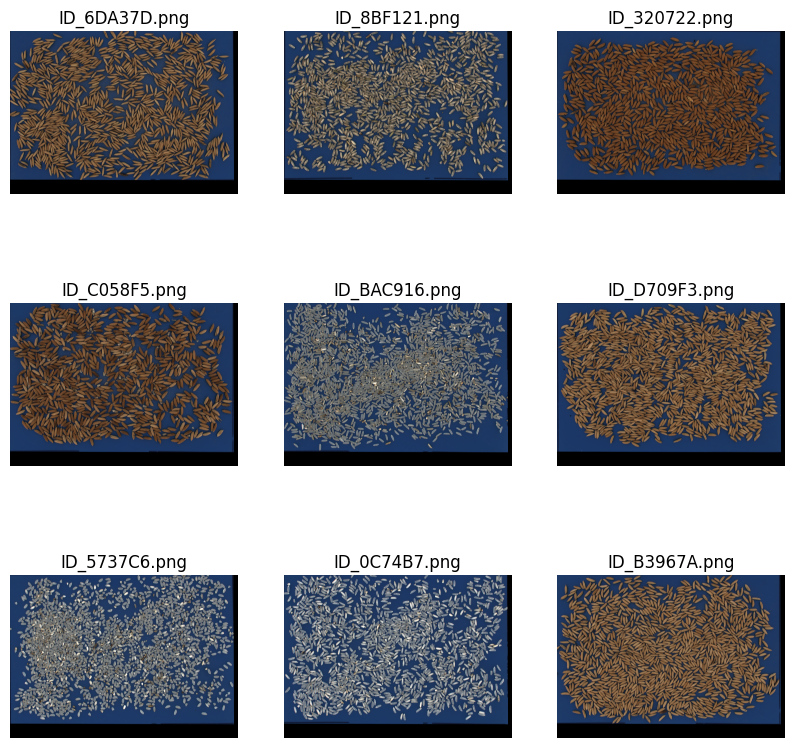

In [10]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_folder = "/content/images"   # change if your folder is different

sample_images = random.sample(os.listdir(image_folder), 9)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_folder, img_name)
    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()

### Distribution of Target Variables

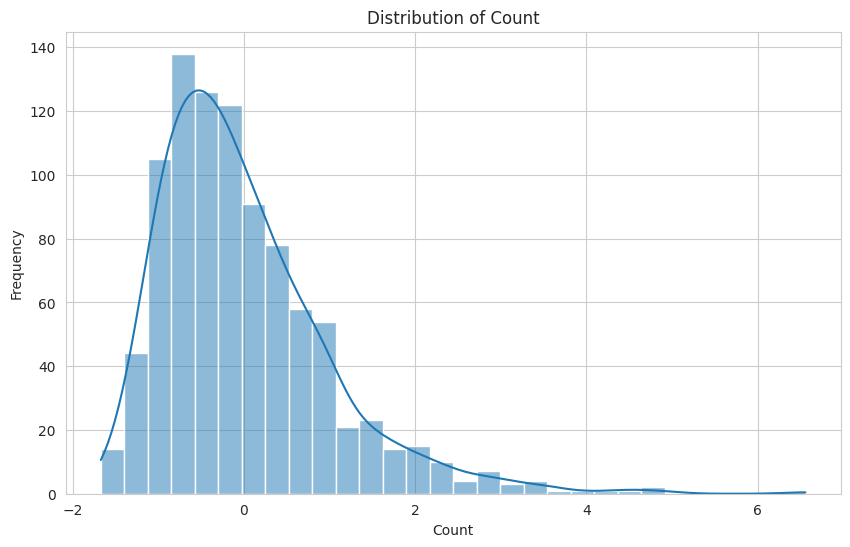

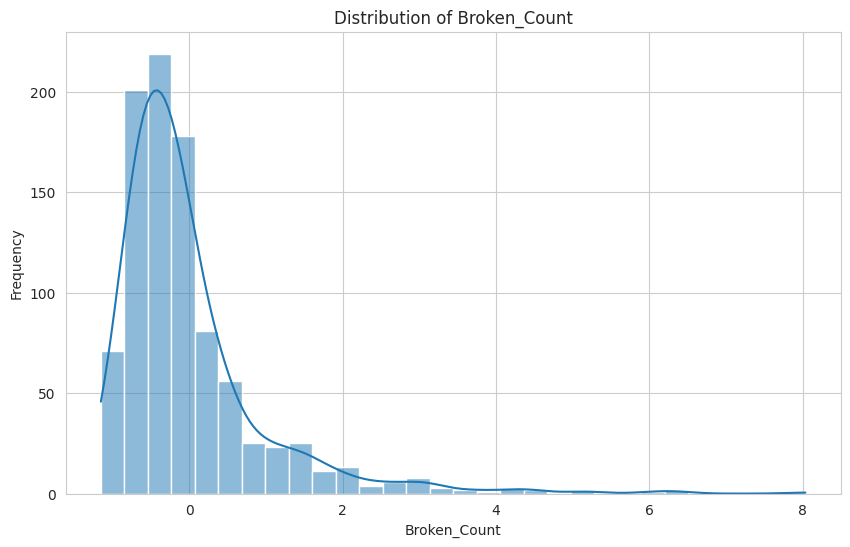

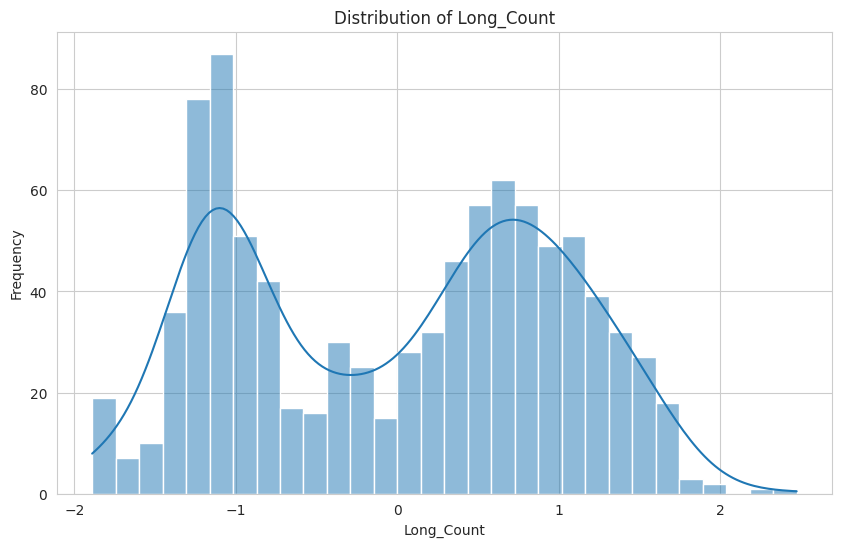

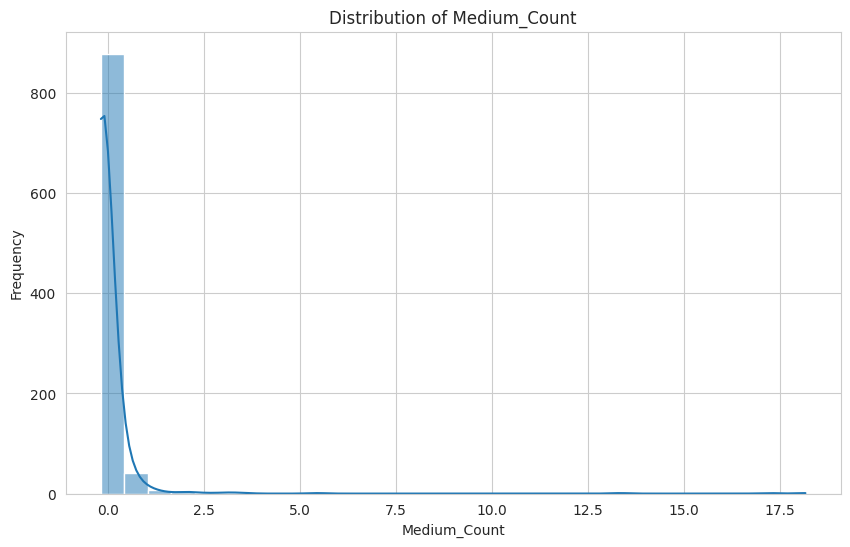

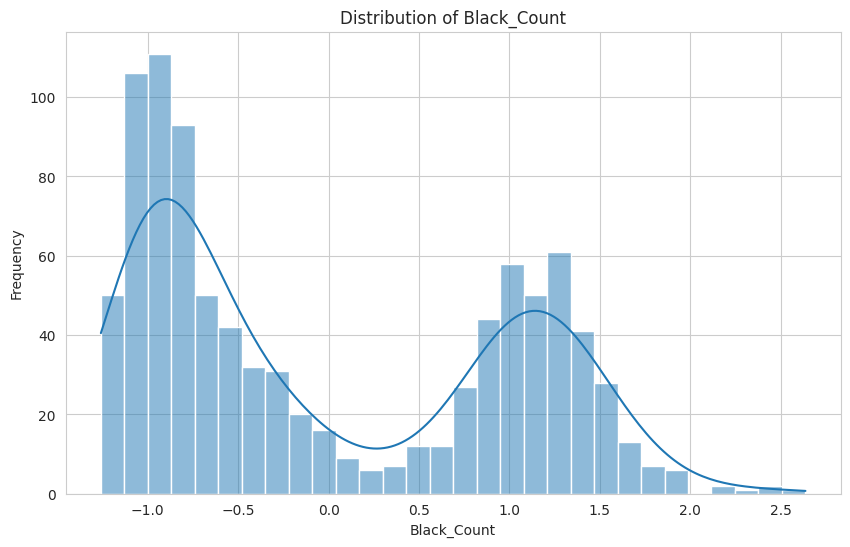

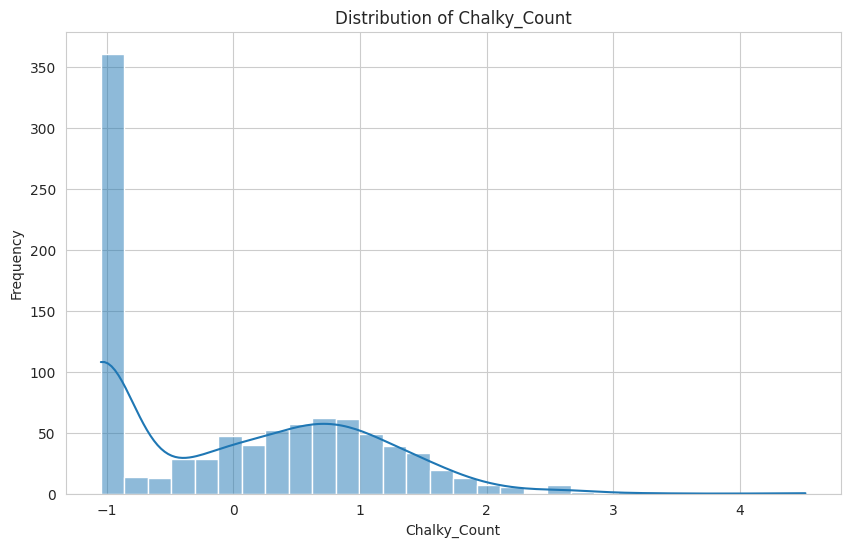

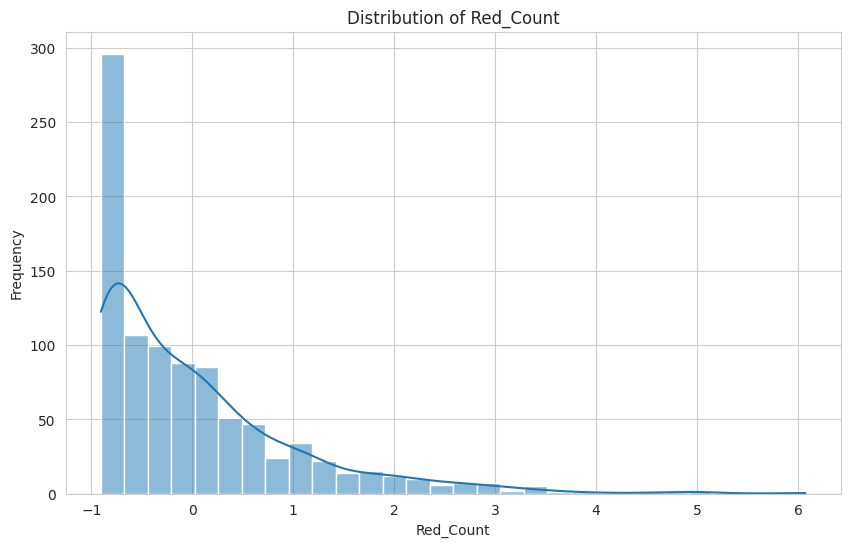

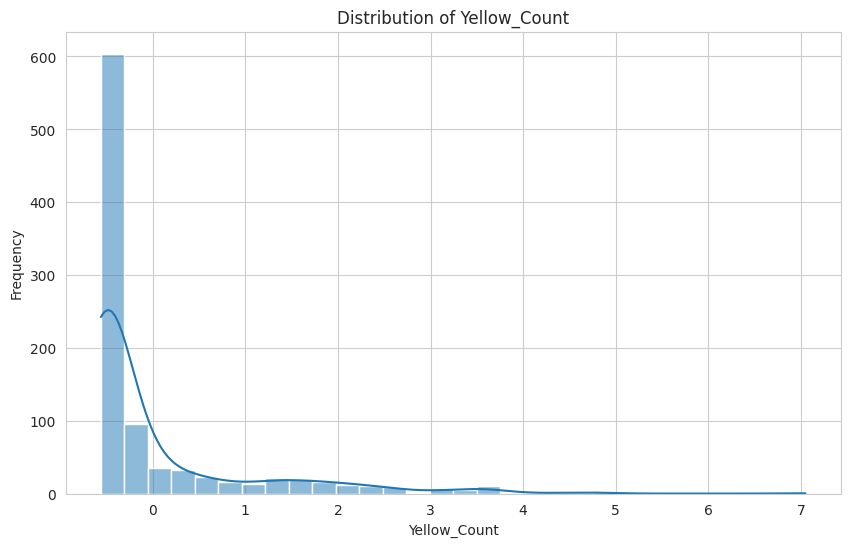

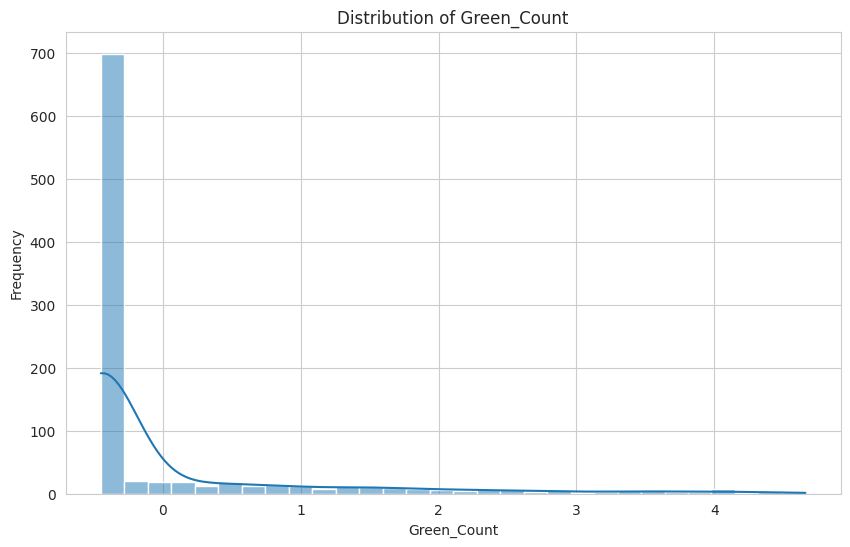

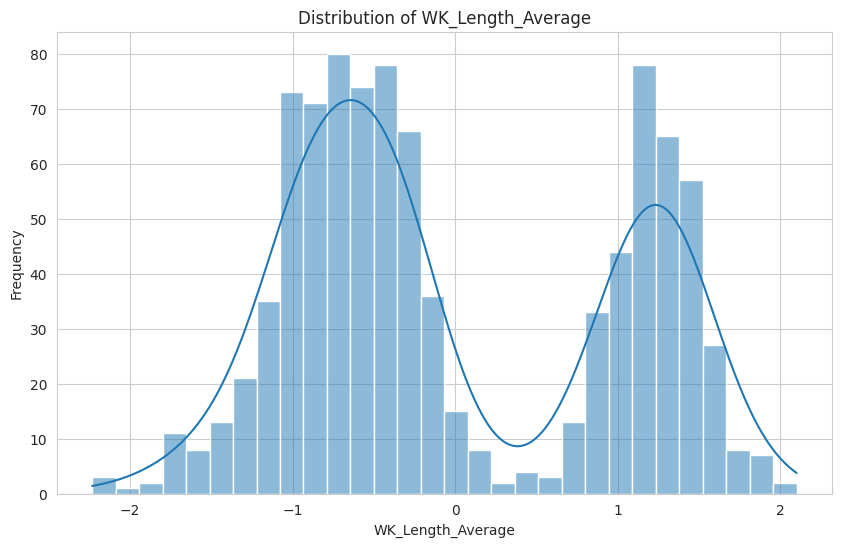

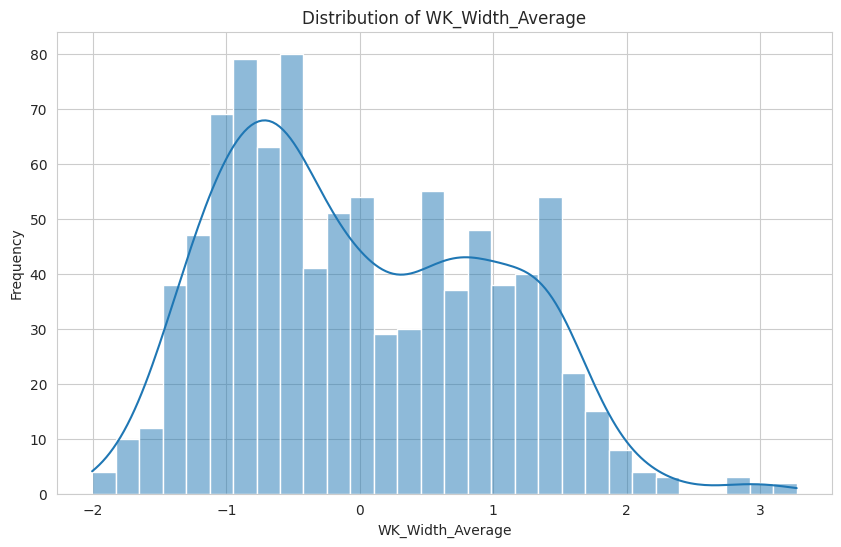

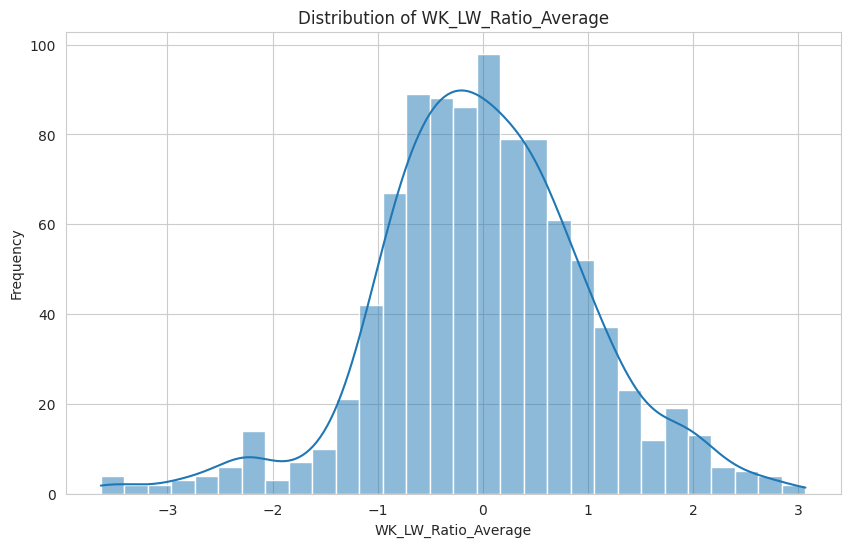

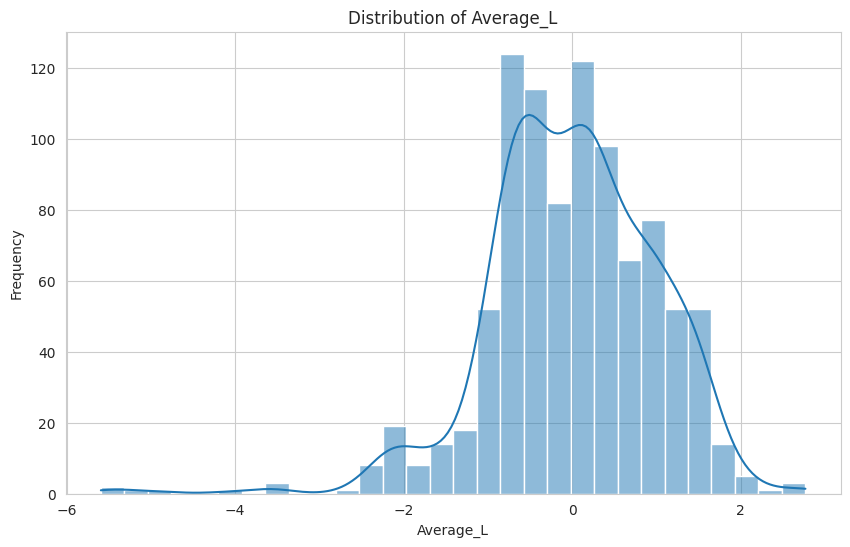

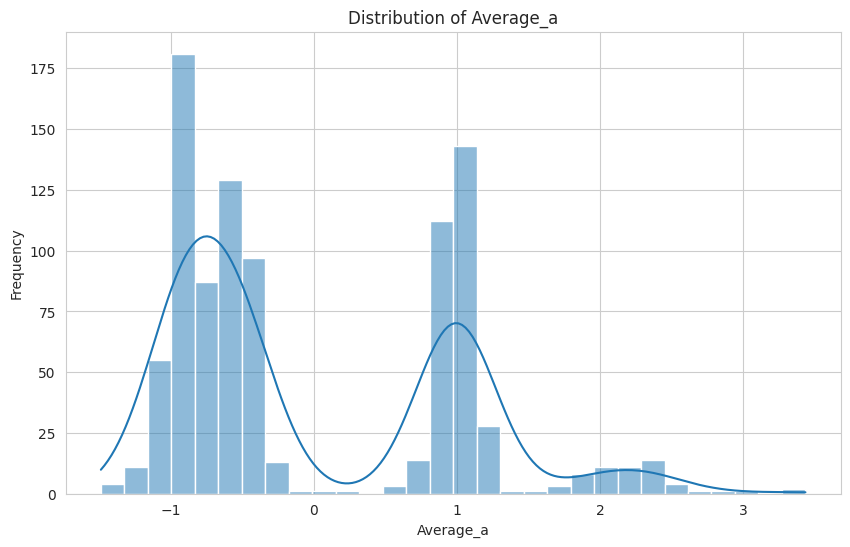

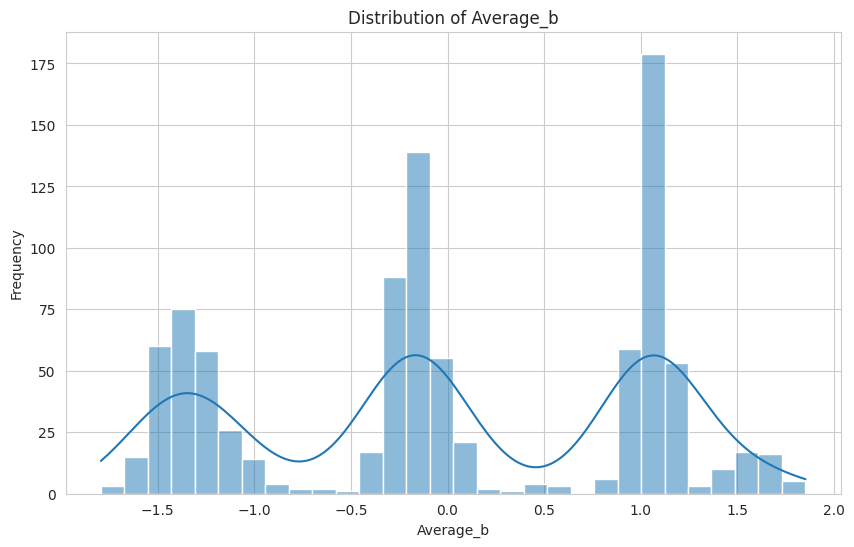

In [ ]:
for col in target_cols:
    plt.figure()
    sns.histplot(train_df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Correlation Heatmap

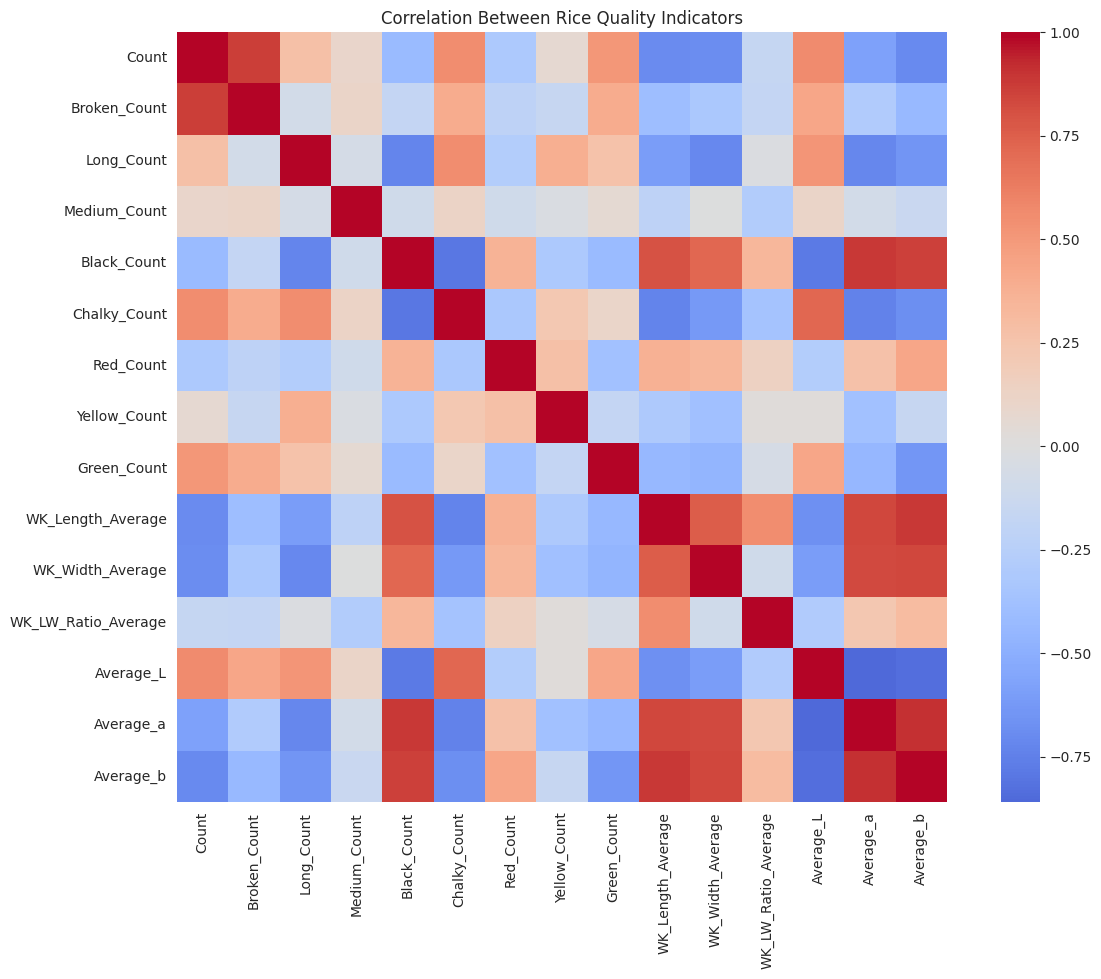

In [ ]:
plt.figure(figsize=(14,10))

corr = train_df[target_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Between Rice Quality Indicators")
plt.show()

### Boxplots to Detect Outliers

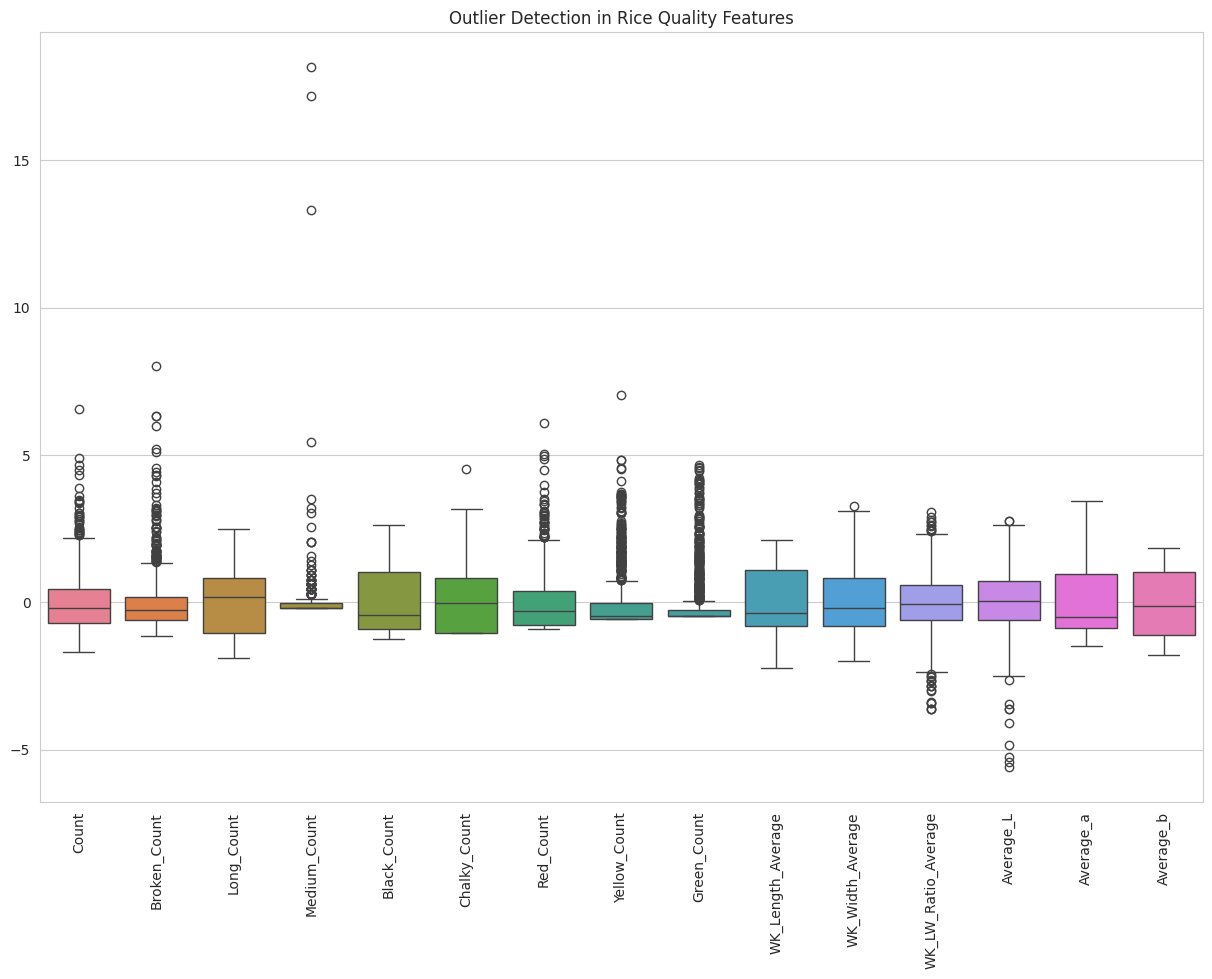

In [ ]:
plt.figure(figsize=(15,10))

sns.boxplot(data=train_df[target_cols])

plt.xticks(rotation=90)
plt.title("Outlier Detection in Rice Quality Features")
plt.show()

### Grain Count Composition

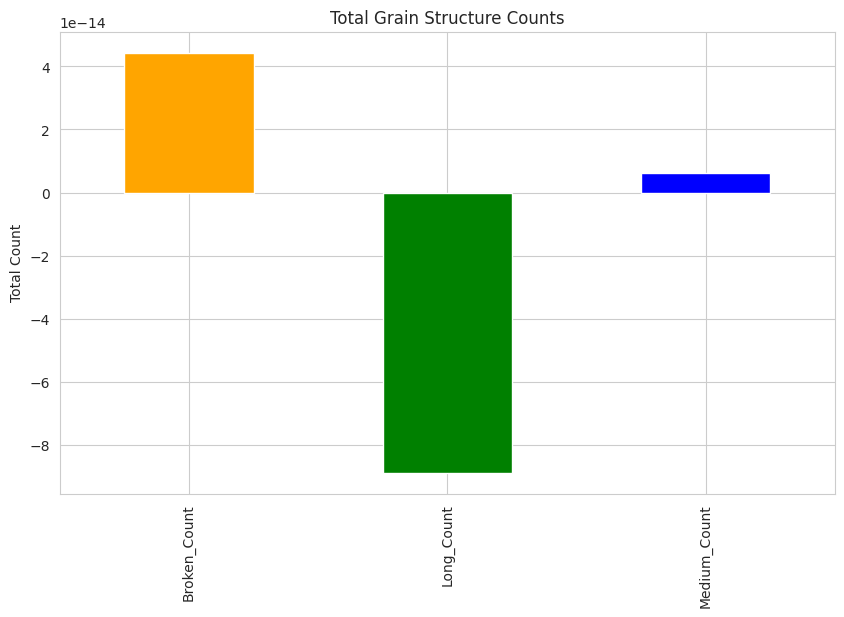

In [ ]:
grain_structure = [
    "Broken_Count",
    "Long_Count",
    "Medium_Count"
]

train_df[grain_structure].sum().plot(
    kind="bar",
    color=["orange","green","blue"]
)

plt.title("Total Grain Structure Counts")
plt.ylabel("Total Count")
plt.show()

### Rice Colour Composition

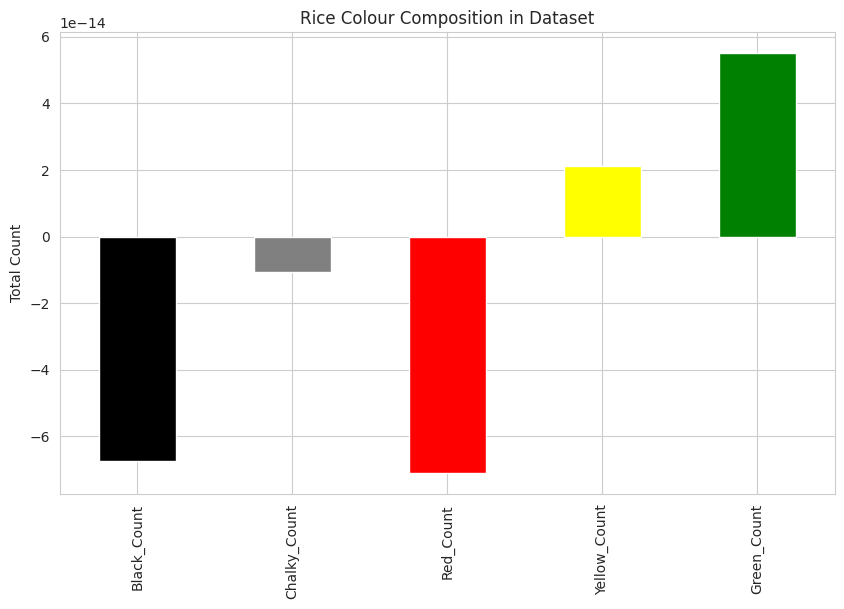

In [ ]:
color_features = [
    "Black_Count",
    "Chalky_Count",
    "Red_Count",
    "Yellow_Count",
    "Green_Count"
]

train_df[color_features].sum().plot(
    kind="bar",
    color=["black","gray","red","yellow","green"]
)

plt.title("Rice Colour Composition in Dataset")
plt.ylabel("Total Count")
plt.show()

### Grain Shape Visualization

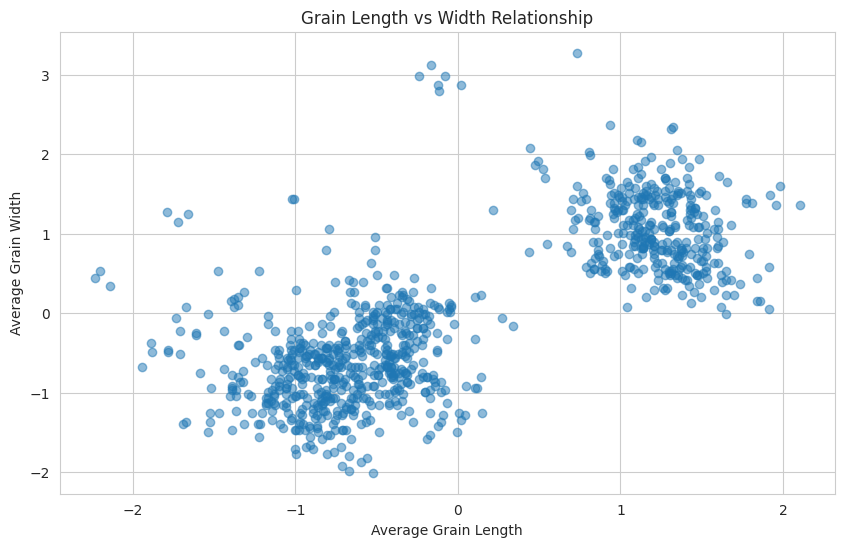

In [ ]:
plt.scatter(
    train_df["WK_Length_Average"],
    train_df["WK_Width_Average"],
    alpha=0.5
)

plt.xlabel("Average Grain Length")
plt.ylabel("Average Grain Width")
plt.title("Grain Length vs Width Relationship")

plt.show()

### Length-to-Width Ratio Distribution

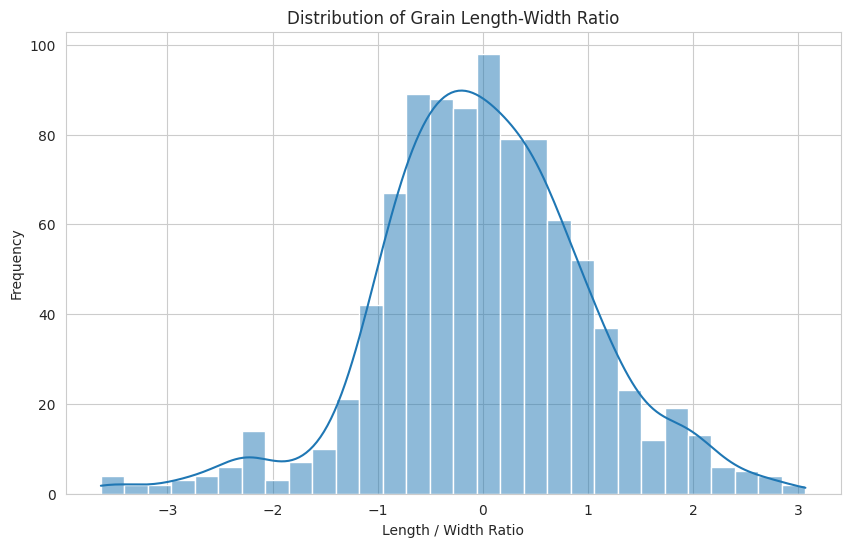

In [ ]:
sns.histplot(train_df["WK_LW_Ratio_Average"], bins=30, kde=True)

plt.title("Distribution of Grain Length-Width Ratio")
plt.xlabel("Length / Width Ratio")
plt.ylabel("Frequency")

plt.show()

### Feature engineering

In [ ]:
train_df["broken_pct"] = train_df["Broken_Count"] / train_df["Count"]
train_df["chalky_pct"] = train_df["Chalky_Count"] / train_df["Count"]
train_df["long_pct"] = train_df["Long_Count"] / train_df["Count"]
train_df["medium_pct"] = train_df["Medium_Count"] / train_df["Count"]

### Scale Target Values

In [ ]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
train_df[target_cols] = target_scaler.fit_transform(train_df[target_cols])

# Save scaler for inverse transform later
import joblib
joblib.dump(target_scaler, "/content/drive/MyDrive/Mission Capstone/Dataset/target_scaler.pkl")

['/content/drive/MyDrive/Mission Capstone/Dataset/target_scaler.pkl']

### Data Train / Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

print("Train split:", train_split_df.shape)
print("Val split:", val_split_df.shape)

Train split: (750, 22)
Val split: (188, 22)


### Build Image Data Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_split_df,
    directory=LOCAL_IMAGE_PATH,
    x_col="filename",
    y_col=target_cols,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_split_df,
    directory=LOCAL_IMAGE_PATH,
    x_col="filename",
    y_col=target_cols,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 750 validated image filenames.
Found 188 validated image filenames.


### Build the Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained base first
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(len(target_cols), activation="linear")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,417,458 (16.85 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Add Training Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "/content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

### Train the Model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 1.2241 - mae: 0.8383 
Epoch 1: val_loss improved from inf to 1.10748, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 391s 16s/step - loss: 1.2223 - mae: 0.8378 - val_loss: 1.1075 - val_mae: 0.7714 - learning_rate: 1.0000e-04
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 1.0285 - mae: 0.7916 
Epoch 2: val_loss improved from 1.10748 to 1.10367, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 349s 15s/step - loss: 1.0307 - mae: 0.7919 - val_loss: 1.1037 - val_mae: 0.7724 - learning_rate: 1.0000e-04
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 1.0956 - mae: 0.8025 
Epoch 3: val_loss improved from 1.10367 to 1.10158, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 352s 15s/step - loss: 1.0938 - mae: 0.8020 - val_loss: 1.1016 - val_mae: 0.7736 - learning_rate: 1.0000e-04
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - loss: 1.0582 - mae: 0.7849 
Epoch 4: val_loss improved from 1.10158 to 1.09811, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 339s 14s/step - loss: 1.0568 - mae: 0.7846 - val_loss: 1.0981 - val_mae: 0.7725 - learning_rate: 1.0000e-04
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 1.0196 - mae: 0.7713 
Epoch 5: val_loss improved from 1.09811 to 1.09764, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


...

24/24 ━━━━━━━━━━━━━━━━━━━━ 359s 15s/step - loss: 0.8338 - mae: 0.6780 - val_loss: 0.9044 - val_mae: 0.6739 - learning_rate: 1.0000e-04
Epoch 46/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 0.7816 - mae: 0.6761 
Epoch 46: val_loss improved from 0.90444 to 0.90323, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 360s 15s/step - loss: 0.7840 - mae: 0.6764 - val_loss: 0.9032 - val_mae: 0.6727 - learning_rate: 1.0000e-04
Epoch 47/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 0.7604 - mae: 0.6597 
Epoch 47: val_loss did not improve from 0.90323
24/24 ━━━━━━━━━━━━━━━━━━━━ 354s 15s/step - loss: 0.7625 - mae: 0.6601 - val_loss: 0.9056 - val_mae: 0.6728 - learning_rate: 1.0000e-04
Epoch 48/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 0.8056 - mae: 0.6587 
Epoch 48: val_loss improved from 0.90323 to 0.90256, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 349s 15s/step - loss: 0.8053 - mae: 0.6587 - val_loss: 0.9026 - val_mae: 0.6713 - learning_rate: 1.0000e-04
Epoch 49/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 0.8181 - mae: 0.6666 
Epoch 49: val_loss improved from 0.90256 to 0.89400, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 368s 15s/step - loss: 0.8175 - mae: 0.6664 - val_loss: 0.8940 - val_mae: 0.6685 - learning_rate: 1.0000e-04
Epoch 50/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 0.7593 - mae: 0.6551 
Epoch 50: val_loss improved from 0.89400 to 0.89087, saving model to /content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 365s 15s/step - loss: 0.7612 - mae: 0.6557 - val_loss: 0.8909 - val_mae: 0.6659 - learning_rate: 1.0000e-04


### Plot Learning Curves

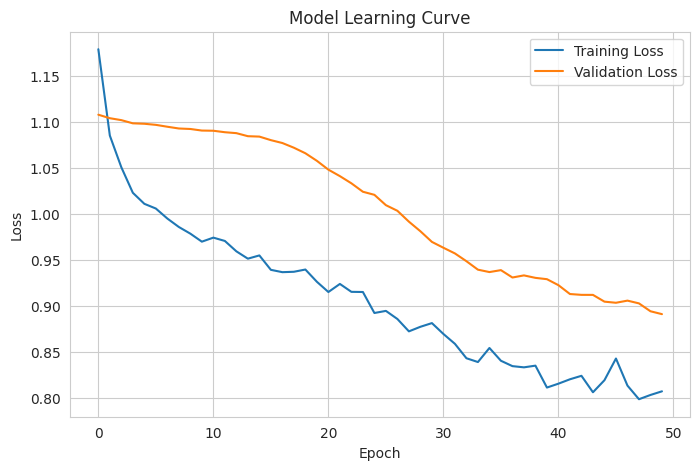

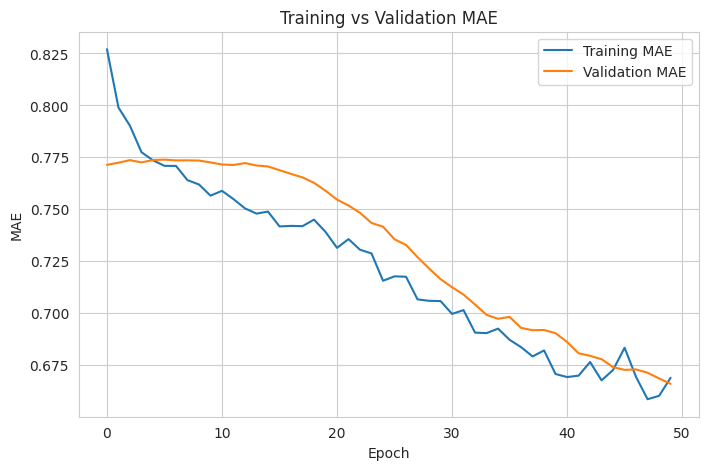

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

### Evaluate the Model on Validation Data

In [ ]:
val_loss, val_mae = model.evaluate(val_generator)
print("Validation Loss:", val_loss)
print("Validation MAE :", val_mae)

6/6 ━━━━━━━━━━━━━━━━━━━━ 68s 11s/step - loss: 0.8426 - mae: 0.6530
Validation Loss: 0.890870988368988
Validation MAE : 0.6659196019172668


### Predict on Validation Set

In [ ]:
y_true = val_split_df[target_cols].values
y_pred = model.predict(val_generator)

6/6 ━━━━━━━━━━━━━━━━━━━━ 68s 10s/step


### Compute Regression Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
r2 = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]

metrics_df = pd.DataFrame({
    "Target": target_cols,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

display(metrics_df.sort_values("MAE"))

,Target,MAE,RMSE,R2
3,Medium_Count,0.321034,1.348300,0.022529
12,Average_L,0.554964,0.780066,0.436675
8,Green_Count,0.562297,1.069045,0.106674
1,Broken_Count,0.570599,0.961709,0.094216
0,Count,0.593749,0.862485,0.213521
5,Chalky_Count,0.641628,0.764414,0.314028
6,Red_Count,0.658217,0.865752,0.100865
14,Average_b,0.681468,0.767188,0.413107
7,Yellow_Count,0.717128,1.078401,0.005665
10,WK_Width_Average,0.747185,0.891250,0.210200


### Inverse Transform Predictions Back to Original Scale

In [ ]:
# Load scaler if needed
target_scaler = joblib.load("/content/drive/MyDrive/Mission Capstone/Dataset/target_scaler.pkl")

y_true_original = target_scaler.inverse_transform(y_true)
y_pred_original = target_scaler.inverse_transform(y_pred)

results_df = pd.DataFrame(y_pred_original, columns=[f"Pred_{c}" for c in target_cols])
true_df = pd.DataFrame(y_true_original, columns=[f"True_{c}" for c in target_cols])

comparison_df = pd.concat([true_df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
display(comparison_df.head())

,True_Count,True_Broken_Count,True_Long_Count,True_Medium_Count,True_Black_Count,True_Chalky_Count,True_Red_Count,True_Yellow_Count,True_Green_Count,True_WK_Length_Average,...,Pred_Chalky_Count,Pred_Red_Count,Pred_Yellow_Count,Pred_Green_Count,Pred_WK_Length_Average,Pred_WK_Width_Average,Pred_WK_LW_Ratio_Average,Pred_Average_L,Pred_Average_a,Pred_Average_b
0,2211.0,1164.0,766.0,4.0,328.0,841.0,3.0,24.0,414.0,6.41,...,485.572266,18.064342,68.522087,75.329720,7.622652,2.555446,3.067032,64.127853,2.710475,15.222020
1,1669.0,500.0,1011.0,0.0,67.0,428.0,0.0,13.0,759.0,6.48,...,542.124573,17.176056,67.825325,81.950424,7.522322,2.527397,3.043719,65.239403,2.058315,13.513187
2,1339.0,123.0,1117.0,0.0,41.0,383.0,0.0,9.0,108.0,6.69,...,432.464203,18.939041,70.450378,65.919312,7.737689,2.597315,3.095684,63.124329,3.421053,16.945303
3,1283.0,217.0,901.0,0.0,190.0,860.0,19.0,214.0,0.0,7.04,...,374.269012,20.199373,74.649185,52.012226,7.883286,2.648584,3.122798,62.166218,4.207887,19.391993
4,1275.0,235.0,870.0,0.0,123.0,1009.0,19.0,124.0,0.0,7.05,...,366.074188,20.353876,75.208855,50.620136,7.906286,2.655833,3.126322,62.013168,4.320104,19.721630


### Visualize True vs Predicted for Important Targets

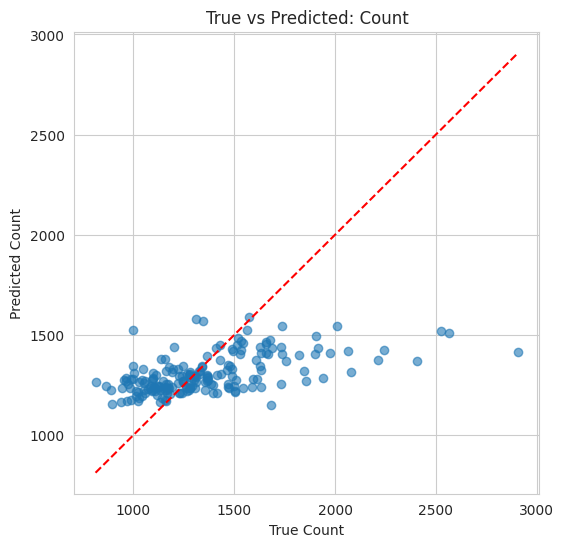

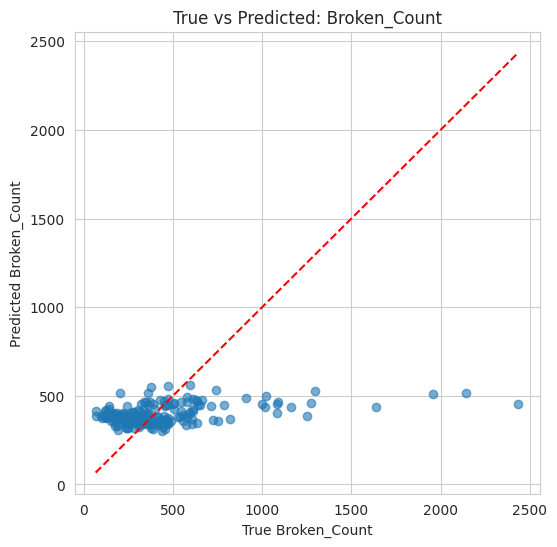

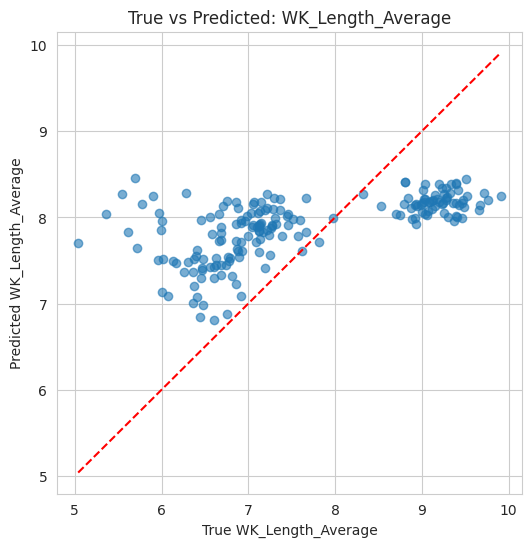

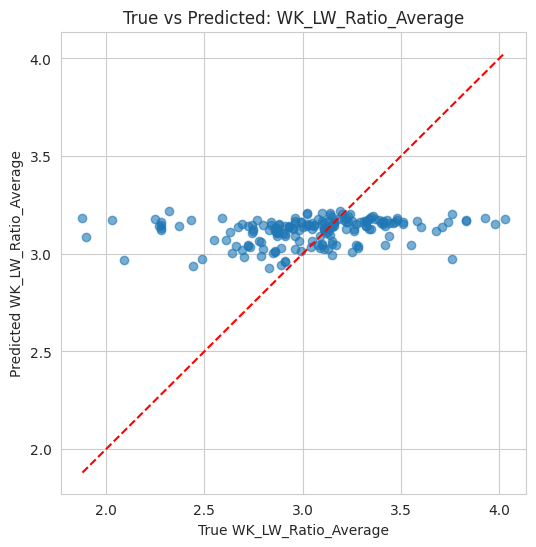

In [ ]:
important_targets = ["Count", "Broken_Count", "WK_Length_Average", "WK_LW_Ratio_Average"]

for col in important_targets:
    if col in target_cols:
        idx = target_cols.index(col)

        plt.figure(figsize=(6,6))
        plt.scatter(y_true_original[:, idx], y_pred_original[:, idx], alpha=0.6)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Predicted {col}")
        plt.title(f"True vs Predicted: {col}")
        plt.plot(
            [y_true_original[:, idx].min(), y_true_original[:, idx].max()],
            [y_true_original[:, idx].min(), y_true_original[:, idx].max()],
            'r--'
        )
        plt.show()

### Save Final Model fro backup

In [ ]:
model.save("/content/drive/MyDrive/Mission Capstone/Dataset/final_rice_model.h5")
print("Final model saved.")

Final model saved.


### Predict on One Image

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_one_image(img_path, model, scaler, target_cols):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred_scaled = model.predict(img)
    pred_original = scaler.inverse_transform(pred_scaled)[0]

    return dict(zip(target_cols, pred_original))

sample_image = os.path.join(LOCAL_IMAGE_PATH, train_df["filename"].iloc[0])
sample_prediction = predict_one_image(sample_image, model, target_scaler, target_cols)

sample_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


{'Count': np.float32(1278.3993),
 'Broken_Count': np.float32(383.83603),
 'Long_Count': np.float32(522.06635),
 'Medium_Count': np.float32(0.92306215),
 'Black_Count': np.float32(735.83856),
 'Chalky_Count': np.float32(333.0909),
 'Red_Count': np.float32(21.068644),
 'Yellow_Count': np.float32(77.547775),
 'Green_Count': np.float32(43.863514),
 'WK_Length_Average': np.float32(8.000536),
 'WK_Width_Average': np.float32(2.6872182),
 'WK_LW_Ratio_Average': np.float32(3.1393864),
 'Average_L': np.float32(61.37565),
 'Average_a': np.float32(4.784925),
 'Average_b': np.float32(21.156715)}

### Convert Raw Outputs into Rice Quality Interpretation

In [ ]:
def interpret_rice_quality(pred):
    count = max(pred.get("Count", 1), 1)
    broken = pred.get("Broken_Count", 0)
    long_count = pred.get("Long_Count", 0)
    medium_count = pred.get("Medium_Count", 0)
    chalky = pred.get("Chalky_Count", 0)
    lw_ratio = pred.get("WK_LW_Ratio_Average", 0)

    broken_pct = (broken / count) * 100
    long_pct = (long_count / count) * 100
    medium_pct = (medium_count / count) * 100
    chalky_pct = (chalky / count) * 100

    # Milling grade
    if broken_pct < 5:
        milling_grade = "Premium"
    elif broken_pct < 10:
        milling_grade = "Grade 1"
    elif broken_pct < 15:
        milling_grade = "Grade 2"
    elif broken_pct < 20:
        milling_grade = "Grade 3"
    else:
        milling_grade = "Below Grade"

    # Grain shape
    if lw_ratio < 2.1:
        grain_shape = "Bold"
    elif 2.1 <= lw_ratio <= 2.9:
        grain_shape = "Medium"
    else:
        grain_shape = "Slender"

    # Grain length class
    if long_pct > 90:
        grain_length_class = "Long Grain"
    elif medium_pct > 90:
        grain_length_class = "Medium Grain"
    else:
        grain_length_class = "Mixed Grain"

    # Chalkiness
    chalkiness_status = "Chalky" if chalky_pct > 20 else "Not Chalky"

    return {
        "broken_pct": broken_pct,
        "long_pct": long_pct,
        "medium_pct": medium_pct,
        "chalky_pct": chalky_pct,
        "milling_grade": milling_grade,
        "grain_shape": grain_shape,
        "grain_length_class": grain_length_class,
        "chalkiness_status": chalkiness_status
    }

interpreted_result = interpret_rice_quality(sample_prediction)
interpreted_result

{'broken_pct': np.float32(30.024736),
 'long_pct': np.float32(40.8375),
 'medium_pct': np.float32(0.07220452),
 'chalky_pct': np.float32(26.055313),
 'milling_grade': 'Below Grade',
 'grain_shape': 'Slender',
 'grain_length_class': 'Mixed Grain',
 'chalkiness_status': 'Chalky'}

### Final Output for AminoRice

In [ ]:
final_output = {
    "raw_model_outputs": sample_prediction,
    "interpreted_quality": interpreted_result
}

final_output

{'raw_model_outputs': {'Count': np.float32(1278.3993),
  'Broken_Count': np.float32(383.83603),
  'Long_Count': np.float32(522.06635),
  'Medium_Count': np.float32(0.92306215),
  'Black_Count': np.float32(735.83856),
  'Chalky_Count': np.float32(333.0909),
  'Red_Count': np.float32(21.068644),
  'Yellow_Count': np.float32(77.547775),
  'Green_Count': np.float32(43.863514),
  'WK_Length_Average': np.float32(8.000536),
  'WK_Width_Average': np.float32(2.6872182),
  'WK_LW_Ratio_Average': np.float32(3.1393864),
  'Average_L': np.float32(61.37565),
  'Average_a': np.float32(4.784925),
  'Average_b': np.float32(21.156715)},
 'interpreted_quality': {'broken_pct': np.float32(30.024736),
  'long_pct': np.float32(40.8375),
  'medium_pct': np.float32(0.07220452),
  'chalky_pct': np.float32(26.055313),
  'milling_grade': 'Below Grade',
  'grain_shape': 'Slender',
  'grain_length_class': 'Mixed Grain',
  'chalkiness_status': 'Chalky'}}

## Make Predictions
### Load the Best Model

In [6]:
import os
import numpy as np
import pandas as pd
import joblib
from PIL import Image
import tensorflow as tf

In [7]:
BEST_MODEL_PATH = "/content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5"
SCALER_PATH = "/content/drive/MyDrive/Mission Capstone/Dataset/target_scaler.pkl"

model = tf.keras.models.load_model(BEST_MODEL_PATH, compile=False)
target_scaler = joblib.load(SCALER_PATH)

print("Best model loaded successfully.")
print("Scaler loaded successfully.")

Best model loaded successfully.
Scaler loaded successfully.


In [8]:
import tensorflow as tf

# load your saved best model
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.h5",
    compile=False
)

# save it in keras format
model.save(
    "/content/drive/MyDrive/Mission Capstone/Dataset/best_rice_model_efficientnetb0.keras"
)

print("Model converted successfully.")

Model converted successfully.


### Define the Exact Target Columns

In [ ]:
target_cols = [
    "Count",
    "Broken_Count",
    "Long_Count",
    "Medium_Count",
    "Black_Count",
    "Chalky_Count",
    "Red_Count",
    "Yellow_Count",
    "Green_Count",
    "WK_Length_Average",
    "WK_Width_Average",
    "WK_LW_Ratio_Average",
    "Average_L",
    "Average_a",
    "Average_b"
]

### Build Image Preprocessing Function

In [ ]:
IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img).astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    return img

### Build Rule-Based Interpretation Function

In [ ]:
def interpret_rice_quality(pred):
    count = max(float(pred.get("Count", 1)), 1.0)
    broken = max(float(pred.get("Broken_Count", 0)), 0.0)
    long_count = max(float(pred.get("Long_Count", 0)), 0.0)
    medium_count = max(float(pred.get("Medium_Count", 0)), 0.0)
    black = max(float(pred.get("Black_Count", 0)), 0.0)
    chalky = max(float(pred.get("Chalky_Count", 0)), 0.0)
    red = max(float(pred.get("Red_Count", 0)), 0.0)
    yellow = max(float(pred.get("Yellow_Count", 0)), 0.0)
    green = max(float(pred.get("Green_Count", 0)), 0.0)
    lw_ratio = float(pred.get("WK_LW_Ratio_Average", 0))

    broken_pct = (broken / count) * 100
    long_pct = (long_count / count) * 100
    medium_pct = (medium_count / count) * 100
    black_pct = (black / count) * 100
    chalky_pct = (chalky / count) * 100
    red_pct = (red / count) * 100
    yellow_pct = (yellow / count) * 100
    green_pct = (green / count) * 100

    # Milling grade
    if broken_pct < 5:
        milling_grade = "Premium"
    elif broken_pct < 10:
        milling_grade = "Grade 1"
    elif broken_pct < 15:
        milling_grade = "Grade 2"
    elif broken_pct < 20:
        milling_grade = "Grade 3"
    else:
        milling_grade = "Below Grade"

    # Grain shape
    if lw_ratio < 2.1:
        grain_shape = "Bold"
    elif 2.1 <= lw_ratio <= 2.9:
        grain_shape = "Medium"
    else:
        grain_shape = "Slender"

    # Grain length class
    if long_pct > 90:
        grain_length_class = "Long Grain"
    elif medium_pct > 90:
        grain_length_class = "Medium Grain"
    else:
        grain_length_class = "Mixed Grain"

    # Chalkiness
    chalkiness_status = "Chalky" if chalky_pct > 20 else "Not Chalky"

    # Simple defect alerts
    alerts = []
    if black_pct > 1:
        alerts.append("Black grains detected")
    if red_pct > 1:
        alerts.append("Red grains detected")
    if yellow_pct > 1:
        alerts.append("Yellow grains detected")
    if green_pct > 1:
        alerts.append("Green grains detected")
    if chalky_pct > 20:
        alerts.append("High chalkiness detected")
    if broken_pct >= 20:
        alerts.append("High broken grain percentage")

    return {
        "broken_percentage": round(broken_pct, 2),
        "long_percentage": round(long_pct, 2),
        "medium_percentage": round(medium_pct, 2),
        "chalky_percentage": round(chalky_pct, 2),
        "black_percentage": round(black_pct, 2),
        "red_percentage": round(red_pct, 2),
        "yellow_percentage": round(yellow_pct, 2),
        "green_percentage": round(green_pct, 2),
        "milling_grade": milling_grade,
        "grain_shape": grain_shape,
        "grain_length_class": grain_length_class,
        "chalkiness_status": chalkiness_status,
        "alerts": alerts
    }

### Build the Single AminoRice Prediction Function

In [ ]:
def amino_rice_predict(image_path, model, scaler, target_cols):
    # preprocess
    img = preprocess_image(image_path)

    # predict scaled outputs
    pred_scaled = model.predict(img, verbose=0)

    # inverse transform back to original units
    pred_original = scaler.inverse_transform(pred_scaled)[0]

    # raw outputs dictionary
    raw_outputs = dict(zip(target_cols, pred_original))

    # clean negative count-like values
    count_like_cols = [
        "Count", "Broken_Count", "Long_Count", "Medium_Count",
        "Black_Count", "Chalky_Count", "Red_Count", "Yellow_Count", "Green_Count"
    ]

    for col in count_like_cols:
        if col in raw_outputs:
            raw_outputs[col] = max(0.0, float(raw_outputs[col]))

    # round outputs nicely
    cleaned_outputs = {}
    for k, v in raw_outputs.items():
        cleaned_outputs[k] = round(float(v), 3)

    # interpret
    interpreted = interpret_rice_quality(cleaned_outputs)

    return {
        "image_path": image_path,
        "raw_model_outputs": cleaned_outputs,
        "interpreted_quality": interpreted
    }

### Test on One Image

In [ ]:
sample_image = "/content/images/ID_2BCAB9.png"
result = amino_rice_predict(sample_image, model, target_scaler, target_cols)
result

{'image_path': '/content/images/ID_2BCAB9.png',
 'raw_model_outputs': {'Count': 1147.77,
  'Broken_Count': 304.108,
  'Long_Count': 443.429,
  'Medium_Count': 0.481,
  'Black_Count': 947.286,
  'Chalky_Count': 131.498,
  'Red_Count': 24.25,
  'Yellow_Count': 88.062,
  'Green_Count': 0.0,
  'WK_Length_Average': 8.467,
  'WK_Width_Average': 2.832,
  'WK_LW_Ratio_Average': 3.222,
  'Average_L': 58.055,
  'Average_a': 7.351,
  'Average_b': 28.559},
 'interpreted_quality': {'broken_percentage': 26.5,
  'long_percentage': 38.63,
  'medium_percentage': 0.04,
  'chalky_percentage': 11.46,
  'black_percentage': 82.53,
  'red_percentage': 2.11,
  'yellow_percentage': 7.67,
  'green_percentage': 0.0,
  'milling_grade': 'Below Grade',
  'grain_shape': 'Slender',
  'grain_length_class': 'Mixed Grain',
  'chalkiness_status': 'Not Chalky',
  'alerts': ['Black grains detected',
   'Red grains detected',
   'Yellow grains detected',
   'High broken grain percentage']}}

### Pretty Print the Result

In [ ]:
import json
print(json.dumps(result, indent=4))

{
    "image_path": "/content/images/ID_2BCAB9.png",
    "raw_model_outputs": {
        "Count": 1147.77,
        "Broken_Count": 304.108,
        "Long_Count": 443.429,
        "Medium_Count": 0.481,
        "Black_Count": 947.286,
        "Chalky_Count": 131.498,
        "Red_Count": 24.25,
        "Yellow_Count": 88.062,
        "Green_Count": 0.0,
        "WK_Length_Average": 8.467,
        "WK_Width_Average": 2.832,
        "WK_LW_Ratio_Average": 3.222,
        "Average_L": 58.055,
        "Average_a": 7.351,
        "Average_b": 28.559
    },
    "interpreted_quality": {
        "broken_percentage": 26.5,
        "long_percentage": 38.63,
        "medium_percentage": 0.04,
        "chalky_percentage": 11.46,
        "black_percentage": 82.53,
        "red_percentage": 2.11,
        "yellow_percentage": 7.67,
        "green_percentage": 0.0,
        "milling_grade": "Below Grade",
        "grain_shape": "Slender",
        "grain_length_class": "Mixed Grain",
        "chalkiness_st

### Show a Simple User-Facing Summary

In [ ]:
def display_amino_summary(result):
    q = result["interpreted_quality"]
    r = result["raw_model_outputs"]

    print("=== AminoRice Quality Report ===")
    print(f"Milling Grade       : {q['milling_grade']}")
    print(f"Grain Shape         : {q['grain_shape']}")
    print(f"Grain Length Class  : {q['grain_length_class']}")
    print(f"Chalkiness Status   : {q['chalkiness_status']}")
    print(f"Broken %            : {q['broken_percentage']}%")
    print(f"Chalky %            : {q['chalky_percentage']}%")
    print(f"L/W Ratio           : {r['WK_LW_Ratio_Average']}")
    print(f"Average Length      : {r['WK_Length_Average']}")
    print(f"Average Width       : {r['WK_Width_Average']}")

    if q["alerts"]:
        print("Alerts              :")
        for alert in q["alerts"]:
            print(f" - {alert}")
    else:
        print("Alerts              : None")

In [ ]:
display_amino_summary(result)

=== AminoRice Quality Report ===
Milling Grade       : Below Grade
Grain Shape         : Slender
Grain Length Class  : Mixed Grain
Chalkiness Status   : Not Chalky
Broken %            : 26.5%
Chalky %            : 11.46%
L/W Ratio           : 3.222
Average Length      : 8.467
Average Width       : 2.832
Alerts              :
 - Black grains detected
 - Red grains detected
 - Yellow grains detected
 - High broken grain percentage


In [ ]:
uploaded_image_path = "        "
result = amino_rice_predict(uploaded_image_path, model, target_scaler, target_cols)
return result